<a href="https://colab.research.google.com/github/Satyabratadas/GeoEmerge_hackathon/blob/master/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd                           # For working with data
pd.set_option("display.max_columns", None)    # Lets us see all columns of the data instead of just a preview
import geopandas as gpd                       # For working with spatial data
import numpy as np                            # For working with numbers
import matplotlib.pyplot as plt               # For making graphs
from datetime import date                     # For formatting dates
from PIL import Image                         # For getting and displaying images from links
import requests                               # For getting information from links
from io import BytesIO                        # For working with types of input and output

import seaborn as sns
import folium
from folium.plugins import HeatMap


end_date = "2026-01-31"

data = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=mosquito_habitat_mapper&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

In [42]:
mosquito = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/globe_mosquito.zip')
land_cover = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/globe_land_cover.zip')




In [43]:
map = folium.Map(location=[28.263363, -83.497652], tiles="Cartodb dark_matter", zoom_start=7)
heat_data = [[point.xy[1][0], point.xy[0][0]] for point in mosquito.geometry]
HeatMap(heat_data).add_to(map)


In [44]:
display(map)


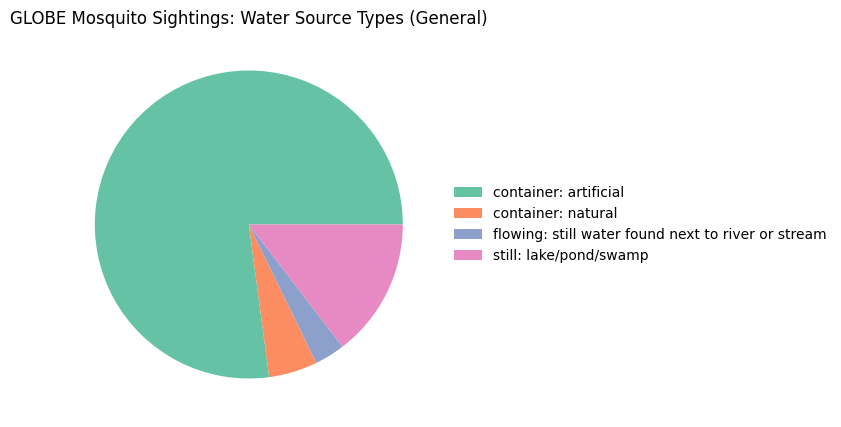

In [45]:
types = mosquito[['SiteId', 'WaterSourceType']].groupby('WaterSourceType', as_index=False).count()

plt.figure(figsize=(5, 5))
patches, texts = plt.pie(x = types['SiteId'],
                         colors = sns.color_palette('Set2'))
plt.title("GLOBE Mosquito Sightings: Water Source Types (General)")
plt.legend(patches, types['WaterSourceType'],
           loc = 'center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.show()


In [47]:
land_cover

,CountryCode,CountryName,Elevation,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,MeasuredDate,geometry
0,ITA,Italy,489.2,GLOBE Observer App,None,None,https://data.globe.gov/system/photos/2024/12/3...,true,None,None,None,https://data.globe.gov/system/photos/2024/12/3...,"Snag C. sativa, 40 cm, cl 2, #01 #04 #12","((compassData.heading: 182, compassData.horizo...",https://data.globe.gov/system/photos/2024/12/3...,"Log 70 cm, C. sativa, cl 2, #04 #01 #12","((compassData.heading: 182, compassData.horizo...",https://data.globe.gov/system/photos/2024/12/3...,Stump of C. sativa 230 cm,"((compassData.heading: null, compassData.horiz...",https://data.globe.gov/system/photos/2024/12/3...,None,None,None,Old Coppice of Castanea sativa,[Conservazione Natura Universita Tuscia],78608,false,8,automatic,2024-12-31 15:07:00.000,492.4,42.1818,12.1825,None,None,,false,None,None,None,https://data.globe.gov/system/photos/2024/12/3...,false,false,None,None,None,https://data.globe.gov/system/photos/2024/12/3...,false,None,None,https://data.globe.gov/system/photos/2024/12/3...,128342138,None,None,None,https://data.globe.gov/system/photos/2024/12/3...,17453129,Italy Citizen Science,land_covers,376869,33TTG673738,2024-12-31,POINT (12.18229 42.18175)
1,MDG,Madagascar,1350.1,GLOBE Observer App,None,None,https://data.globe.gov/system/photos/2024/12/3...,true,None,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",None,https://data.globe.gov/system/photos/2024/12/3...,None,None,None,None,None,None,None,None,None,None,None,None,Arbres plantés par l'équipe GLOBE avec la comm...,"[Africa 2024 Regional Meeting, Coordinating Of...",77695,true,10,automatic,2024-12-31 11:29:00.000,1340.6,-18.7576,47.5615,M01,"Trees, Closely Spaced, Evergreen - Needle Leaved",n,false,None,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",None,https://data.globe.gov/system/photos/2024/12/3...,false,false,None,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",None,https://data.globe.gov/system/photos/2024/12/3...,false,None,None,https://data.globe.gov/system/photos/2024/12/3...,2538037,None,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",None,https://data.globe.gov/system/photos/2024/12/3...,6508873,Madagascar GLOBE v-School,land_covers,373647,38KQE700240,2024-12-31,POINT (47.56096 -18.75807)
2,MDG,Madagascar,1324.7,GLOBE Observer App,None,None,https://data.globe.gov/system/photos/2024/12/3...,true,None,"60% MUC 93 [Urban, Roads and Parking]",None,https://data.globe.gov/system/photos/2024/12/3...,None,None,None,None,None,None,None,None,None,None,None,None,None,"[Africa 2024 Regional Meeting, Coordinating Of...",77691,true,10,automatic,2024-12-31 12:07:00.000,1324.8,-18.7944,47.5799,M93,"Urban, Roads and Parking",,false,None,"60% MUC 93 [Urban, Roads and Parking]",None,https://data.globe.gov/system/photos/2024/12/3...,false,false,None,"60% MUC 93 [Urban, Roads and Parking]",None,https://data.globe.gov/system/photos/2024/12/3...,false,None,None,https://data.globe.gov/system/photos/2024/12/3...,2538037,None,"60% MUC 93 [Urban, Roads and Parking]",None,https://data.globe.gov/system/photos/2024/12/3...,6508873,Madagascar GLOBE v-School,land_covers,373642,38KQE719199,2024-12-31,POIN

In [52]:
florida_only = land_cover[
    (land_cover["CountryCode"] == "USA") & (land_cover.geometry.x.between(-87, -79)) & (land_cover.geometry.y.between(24, 31))
].copy()

In [53]:
florida_only.shape

(501, 64)

In [51]:
florida_only

,CountryCode,CountryName,Elevation,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,MeasuredDate,geometry
1751,USA,United States,4.5,GLOBE Observer App,None,None,https://data.globe.gov/system/photos/2024/10/1...,true,None,"20% MUC 11 (n) [Trees, Loosely Spaced, Evergre...",None,https://data.globe.gov/system/photos/2024/10/1...,None,None,None,None,None,None,None,None,None,None,None,None,None,[Oregon State University GEOGRAPHY],75925,true,8,automatic,2024-10-12 17:35:00.000,4.8,30.3748,-86.2233,M92,"Urban, Commercial Property",,false,None,"10% MUC 11 (n) [Trees, Loosely Spaced, Evergre...",None,https://data.globe.gov/system/photos/2024/10/1...,false,false,None,"10% MUC 02 (b) [Trees, Closely Spaced, Deciduo...",None,https://data.globe.gov/system/photos/2024/10/1...,false,None,None,https://data.globe.gov/system/photos/2024/10/1...,137612022,None,"20% MUC 32 (c) [Shrubs, Closely Spaced, Short ...",None,https://data.globe.gov/system/photos/2024/10/1...,17043304,United States of America Citizen Science,land_covers,367042,16REU746605,2024-10-12,POINT (-86.22361 30.37414)
2659,USA,United States,75.2,GLOBE Observer App,None,None,https://data.globe.gov/system/photos/2024/09/0...,false,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,None,None,None,None,None,None,None,None,None,None,None,None,None,[Oregon State University GEOGRAPHY],75037,true,16,automatic,2024-09-05 00:19:00.000,74.5,27.9671,-81.9234,None,None,,false,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,true,false,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,false,None,None,https://data.globe.gov/system/photos/2024/09/0...,132197353,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,17043304,United States of America Citizen Science,land_covers,358196,17RML091939,2024-09-05,POINT (-81.9242 27.96708)
2664,USA,United States,75.1,GLOBE Observer App,None,None,https://data.globe.gov/system/photos/2024/09/0...,true,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,None,None,None,None,None,None,None,None,None,None,None,None,None,[Oregon State University GEOGRAPHY],75057,true,24,automatic,2024-09-05 21:57:00.000,74.9,27.967,-81.9234,None,None,,false,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,false,false,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,false,None,None,https://data.globe.gov/system/photos/2024/09/0...,132197353,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,17043304,United States of America Citizen Science,land_covers,363475,17RML091938,2024-09-05,POINT (-81.9242 27.96618)
2672,USA,United States,75.2,GLOBE Observer App,None,None,https://data.globe.gov/system/photos/2024/09/0...,true,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,None,None,None,None,None,None,None,None,None,None,None,None,None,[Oregon State University GEOGRAPHY],75058,true,71,automatic,2024-09-05 21:59:00.000,74.5,27.9671,-81.9234,None,None,,false,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,false,false,None,None,None,https://data.globe.gov/system/photos/2024/09/0...,false,None,None,https://data.globe.gov/system/photos/2024/09/0...,1321

In [62]:
fl_data = data[data["countryName"] == "United States"].copy()
fl_data = fl_data.cx[-87:-79, 24:31]  #FL bounding box
fl_data = fl_data.rename(columns={"siteId": "SiteId"})

In [60]:
fl_data

,countryCode,countryName,elevation,mosquitohabitatmapperAbdomenCloseupPhotoUrls,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperComments,mosquitohabitatmapperDataSource,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperGlobeTeams,mosquitohabitatmapperLarvaFullBodyPhotoUrls,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperLastIdentifyStage,mosquitohabitatmapperLocationAccuracyM,mosquitohabitatmapperLocationMethod,mosquitohabitatmapperMeasuredAt,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMeasurementLatitude,mosquitohabitatmapperMeasurementLongitude,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggCount,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoHabitatMapperId,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperUserid,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourcePhotoUrls,mosquitohabitatmapperWaterSourceType,organizationId,organizationName,protocol,SiteID,siteName,geometry
941,USA,United States,14.0,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,None,null,0,null,23,automatic,2025-11-04 17:41:00,0,30.5089,-86.5028,null,null,null,49205,false,null,159641339,jar,https://data.globe.gov/system/photos/2025/11/0...,container: artificial,17043304,United States of America Citizen Science,mosquito_habitat_mapper,403045,16REU477752,POINT (-86.50288 30.50815)
942,USA,United States,14.0,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,None,null,0,null,null,manual,2025-11-04 20:38:00,0,30.5088,-86.5028,null,null,null,49206,false,null,159641339,jar,https://data.globe.gov/system/photos/2025/11/0...,container: artificial,17043304,United States of America Citizen Science,mosquito_habitat_mapper,403045,16REU477752,POINT (-86.50288 30.50815)
1282,USA,United States,2.8,null,false,Canal in City running from inland to ocean.,GLOBE Observer App,LarvaeVisibleNo,null,None,null,0,null,20,automatic,2025-10-08 12:15:00,0,26.2154,-80.2169,null,null,null,48840,false,null,171829152,"puddle or still water next to a creek, stream ...",null,flowing: still water found next to river or st...,10532858,GLOBE Implementation Office GLOBE v-School,mosquito_habitat_mapper,400104,17RNJ782997,POINT (-80.21719 26.21473)
3160,USA,United States,3.5,null,false,null,GLOBE Observer App,LarvaeVisibleNo,null,None,null,0,null,31,automatic,2025-03-12 18:24:00,0,28.3521,-80.6053,null,null,null,46774,false,null,148137248,plant clumps (bamboo etc),https://data.globe.gov/system/photos/2025/03/1...,container: natural,17043304,United States of America Citizen Science,mosquito_habitat_mapper,380362,17RNM386362,POINT (-80.60613 28.35146)
3171,USA,United States,43.6,null,true,null,GLOBE Observer App,LarvaeVisibleYes,null,None,null,12,identify,12,automatic,2025-03-07 18:41:00,0,28.2852,-81.6414,true,null,false,46775,true,null,36036190,estuary,null,flowing: still water found next to river or st...,10532858,GLOBE Implementation Office GLOBE v-School,mosquito_habitat_mapper,380476,17RMM371289,POINT (-81.64142 28.28463)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42490,USA,United States,25.4,null,true,null,GLOBE Observer App,null,null,None,null,3,identify,None,None,2018-12-29 22:41:00,0,28.1407,-82.4334,false,null,true,6222,false,null,51180976,animal trough or water bowl,null,container: artificial,51181115,Graves Elementary,mosquito_habitat_mapper,143718,17RLM592136,POINT (-82.4338 28.14052)
42491,USA,United States,25.4,null,true,null,GLOBE Observer App,null,null,None,null,null,null,None,None,2018-12-29 22:20:00,0,28.1408,-82.4336,null,null,null,6219,false,null,51228147,"puddle, vehhicle or animal tracks",https://data.globe.gov/system/photos/2018/12/2...,still: lake/pond/swamp,17043304,United States of America Citizen Science,mosquito_habitat_mapper,143719,17RLM592136,POINT (-82.4338 28.14052)
42494,USA,United States,25.4,n

In [63]:
merged = pd.merge(florida_only, fl_data, on="SiteId")

In [65]:
merged.shape

(177, 98)